# Plotting a graph over time of the affilitions

In [1]:
import pandas as pd
import numpy as np
melted_master_condenced = pd.read_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.2/QJE_Melted_Weights_applied.xlsx') 
print(melted_master_condenced.shape)
melted_master_condenced = melted_master_condenced[['Article_ID','Weight','Affiliation','year']]
melted_master_condenced = melted_master_condenced.reset_index(drop=True)
melted_master_condenced.head()

(5172, 7)


,Article_ID,Weight,Affiliation,year
0,1883343,1.0,Harvard University,1940
1,1884728,1.0,University Of Utah,1940
2,1884726,1.0,Harvard University,1940
3,1884725,1.0,Harvard University,1940
4,1884724,1.0,Wayne State University,1940


In [2]:
melted_master_condenced['decade'] = ''
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1940) & (melted_master_condenced['year'] < 1950), '[1940,1949]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1950) & (melted_master_condenced['year'] < 1960), '[1950,1959]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1960) & (melted_master_condenced['year'] < 1970), '[1960,1969]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1970) & (melted_master_condenced['year'] < 1980), '[1970,1979]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1980) & (melted_master_condenced['year'] < 1990), '[1980,1989]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1990) & (melted_master_condenced['year'] < 2000), '[1990,1999]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 2000) & (melted_master_condenced['year'] < 2011), '[2000,2010]', melted_master_condenced['decade'])
print(melted_master_condenced.head())
print(melted_master_condenced.tail())

   Article_ID  Weight             Affiliation  year       decade
0     1883343     1.0      Harvard University  1940  [1940,1949]
1     1884728     1.0      University Of Utah  1940  [1940,1949]
2     1884726     1.0      Harvard University  1940  [1940,1949]
3     1884725     1.0      Harvard University  1940  [1940,1949]
4     1884724     1.0  Wayne State University  1940  [1940,1949]
      Article_ID    Weight                     Affiliation  year       decade
5167    27867505  0.125000             Ecole Polytechnique  2010  [2000,2010]
5168    27867507  0.333333          U.S. Air Force Academy  2010  [2000,2010]
5169    27867508  0.333333                 Duke University  2010  [2000,2010]
5170    40961018  0.166667  Hebrew University Of Jerusalem  2010  [2000,2010]
5171    40506283  0.250000        Sorin Capital Management  2010  [2000,2010]


# Ranking the Universities based on their number of papers per published per decade

In [3]:
#Gets the top 10 overall
melted_master_condenced = melted_master_condenced.sort_values(by=['year'])
melted_master_condenced['aff_cum_sum'] = melted_master_condenced.groupby(['Affiliation'])['Weight'].cumsum()

mask_journal = melted_master_condenced['Affiliation'].isin(['National Bureau Of Economic Research'])
melted_master_condenced = melted_master_condenced[~mask_journal]

highest_vals = melted_master_condenced.drop_duplicates(subset = ['Affiliation'], keep = 'last')
highest_vals_10 = highest_vals.nlargest(25,'aff_cum_sum')
print(highest_vals_10.shape)
#print(highest_vals_10.head())
print(highest_vals_10.iat[6,2])

melted_master_condenced_decade = melted_master_condenced[['Article_ID','Weight','Affiliation','decade']]

a = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[6,2]]
a['aff_cum_counts_yearly'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
a = a.drop_duplicates(subset = ['decade'], keep = 'last')
print(a.head())
print(a.shape)

(25, 6)
Yale University


      Article_ID    Weight      Affiliation       decade  \
282      1882838  1.000000  Yale University  [1940,1949]   
640      1883724  1.000000  Yale University  [1950,1959]   
1082     1883990  1.000000  Yale University  [1960,1969]   
1599     1885997  0.333333  Yale University  [1970,1979]   
2500     1885115  1.000000  Yale University  [1980,1989]   

      aff_cum_counts_yearly  
282                7.000000  
640                5.000000  
1082              12.500000  
1599              15.333333  
2500              11.666667  
(7, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_18185/1670870116.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['aff_cum_counts_yearly'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()


In [4]:
a = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[0,2]]
a['aff_cum_sum_decade'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
a = a.drop_duplicates(subset = ['decade'], keep = 'last')
print(a.shape)

b = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[1,2]]
b['aff_cum_sum_decade'] = b.groupby(['Affiliation','decade'])['Weight'].cumsum()
b = b.drop_duplicates(subset = ['decade'], keep = 'last')
print(b.shape)

c = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[2,2]]
c['aff_cum_sum_decade'] = c.groupby(['Affiliation','decade'])['Weight'].cumsum()
c = c.drop_duplicates(subset = ['decade'], keep = 'last')
print(c.shape)

d = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[3,2]]
d['aff_cum_sum_decade'] = d.groupby(['Affiliation','decade'])['Weight'].cumsum()
d = d.drop_duplicates(subset = ['decade'], keep = 'last')
print(d.shape)

e = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[4,2]]
e['aff_cum_sum_decade'] = e.groupby(['Affiliation','decade'])['Weight'].cumsum()
e = e.drop_duplicates(subset = ['decade'], keep = 'last')
print(e.shape)

f = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[5,2]]
f['aff_cum_sum_decade'] = f.groupby(['Affiliation','decade'])['Weight'].cumsum()
f = f.drop_duplicates(subset = ['decade'], keep = 'last')
print(f.shape)

g = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[6,2]]
g['aff_cum_sum_decade'] = g.groupby(['Affiliation','decade'])['Weight'].cumsum()
g = g.drop_duplicates(subset = ['decade'], keep = 'last')
print(g.shape)

h = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[7,2]]
h['aff_cum_sum_decade'] = h.groupby(['Affiliation','decade'])['Weight'].cumsum()
h = h.drop_duplicates(subset = ['decade'], keep = 'last')
print(h.shape)

i = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[8,2]]
i['aff_cum_sum_decade'] = i.groupby(['Affiliation','decade'])['Weight'].cumsum()
i = i.drop_duplicates(subset = ['decade'], keep = 'last')
print(i.shape)

j = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[9,2]]
j['aff_cum_sum_decade'] = j.groupby(['Affiliation','decade'])['Weight'].cumsum()
j = j.drop_duplicates(subset = ['decade'], keep = 'last')
print(j.shape)

k = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[10,2]]
k['aff_cum_sum_decade'] = k.groupby(['Affiliation','decade'])['Weight'].cumsum()
k = k.drop_duplicates(subset = ['decade'], keep = 'last')
print(k.shape)

l = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[11,2]]
l['aff_cum_sum_decade'] = l.groupby(['Affiliation','decade'])['Weight'].cumsum()
l = l.drop_duplicates(subset = ['decade'], keep = 'last')
print(l.shape)

m = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[12,2]]
m['aff_cum_sum_decade'] = m.groupby(['Affiliation','decade'])['Weight'].cumsum()
m = m.drop_duplicates(subset = ['decade'], keep = 'last')
print(m.shape)

n = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[13,2]]
n['aff_cum_sum_decade'] = n.groupby(['Affiliation','decade'])['Weight'].cumsum()
n = n.drop_duplicates(subset = ['decade'], keep = 'last')
print(n.shape)

o = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[14,2]]
o['aff_cum_sum_decade'] = o.groupby(['Affiliation','decade'])['Weight'].cumsum()
o = o.drop_duplicates(subset = ['decade'], keep = 'last')
print(o.shape)

p = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[15,2]]
p['aff_cum_sum_decade'] = p.groupby(['Affiliation','decade'])['Weight'].cumsum()
p = p.drop_duplicates(subset = ['decade'], keep = 'last')
print(p.shape)

q = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[16,2]]
q['aff_cum_sum_decade'] = q.groupby(['Affiliation','decade'])['Weight'].cumsum()
q = q.drop_duplicates(subset = ['decade'], keep = 'last')
print(q.shape)

r = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[17,2]]
r['aff_cum_sum_decade'] = r.groupby(['Affiliation','decade'])['Weight'].cumsum()
r = r.drop_duplicates(subset = ['decade'], keep = 'last')
print(r.shape)

s = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[18,2]]
s['aff_cum_sum_decade'] = s.groupby(['Affiliation','decade'])['Weight'].cumsum()
s = s.drop_duplicates(subset = ['decade'], keep = 'last')
print(s.shape)

t = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[19,2]]
t['aff_cum_sum_decade'] = t.groupby(['Affiliation','decade'])['Weight'].cumsum()
t = t.drop_duplicates(subset = ['decade'], keep = 'last')
print(t.shape)

u = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[20,2]]
u['aff_cum_sum_decade'] = u.groupby(['Affiliation','decade'])['Weight'].cumsum()
u = u.drop_duplicates(subset = ['decade'], keep = 'last')
print(u.shape)

v = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[21,2]]
v['aff_cum_sum_decade'] = v.groupby(['Affiliation','decade'])['Weight'].cumsum()
v = v.drop_duplicates(subset = ['decade'], keep = 'last')
print(v.shape)

w = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[22,2]]
w['aff_cum_sum_decade'] = w.groupby(['Affiliation','decade'])['Weight'].cumsum()
w = w.drop_duplicates(subset = ['decade'], keep = 'last')
print(w.shape)

x = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[23,2]]
x['aff_cum_sum_decade'] = x.groupby(['Affiliation','decade'])['Weight'].cumsum()
x = x.drop_duplicates(subset = ['decade'], keep = 'last')
print(x.shape)

y = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[24,2]]
y['aff_cum_sum_decade'] = y.groupby(['Affiliation','decade'])['Weight'].cumsum()
y = y.drop_duplicates(subset = ['decade'], keep = 'last')
print(y.shape)

/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_18185/1100585584.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['aff_cum_sum_decade'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_18185/1100585584.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b['aff_cum_sum_decade'] = b.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_18185/1100585584.py:12: SettingWith

(7, 5)
(7, 5)
(7, 5)
(7, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_18185/1100585584.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  e['aff_cum_sum_decade'] = e.groupby(['Affiliation','decade'])['Weight'].cumsum()


(7, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_18185/1100585584.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f['aff_cum_sum_decade'] = f.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_18185/1100585584.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  g['aff_cum_sum_decade'] = g.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_18185/1100585584.py:37: SettingWi

(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(6, 5)
(7, 5)
(3, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_18185/1100585584.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r['aff_cum_sum_decade'] = r.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_18185/1100585584.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s['aff_cum_sum_decade'] = s.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_18185/1100585584.py:97: SettingWi

(6, 5)
(6, 5)
(5, 5)
(6, 5)
(7, 5)
(5, 5)
(5, 5)
(7, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_18185/1100585584.py:102: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  u['aff_cum_sum_decade'] = u.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_18185/1100585584.py:107: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  v['aff_cum_sum_decade'] = v.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_18185/1100585584.py:112: Settin

In [5]:
#ranked = pd.concat([a,b,c,d,e,f,g,h,i,j], axis=0)
#ranked = pd.concat([a,b,c,d,e,f,g,h,i,j,k,l,m,n,o], axis=0)
#ranked = pd.concat([a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,q,r,s,t], axis=0)
ranked = pd.concat([a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,q,r,s,t,u,v,w,x,y], axis=0)
ranked = ranked.sort_values(by=['decade','Affiliation'])
print(ranked.shape)

ranked['Rank'] = ranked.groupby(['decade'])['aff_cum_sum_decade'].rank(method = 'max', ascending= False)
print(ranked.shape)
print(ranked.tail(20))
#ranked.to_excel('/Users/MattJohnson/Desktop/Affiliations/2_Extracting affilitations/2_Fuzzy matching/Combined journals/Combined journal yearly rank.xlsx') 

(161, 5)
(161, 6)
      Article_ID    Weight                                     Affiliation  \
5072    27867504  0.500000                             Columbia University   
4606    25098880  0.500000                              Cornell University   
5070    27867488  0.250000                              Harvard University   
5170    40961018  0.166667                  Hebrew University Of Jerusalem   
5087    40961019  0.166667  London School Of Economics & Political Science   
5089    27867488  0.250000           Massachusetts Institute Of Technology   
5071    27867503  0.250000                             New York University   
5061    27867494  0.500000                         Northwestern University   
5068    40961019  0.500000                            Princeton University   
5150    27867502  0.333333                             Stanford University   
5144    40506280  0.500000              University Of California, Berkeley   
5075    27867507  0.333333                 Uni

In [6]:
#ranked.to_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.3/JPE_Ranked_data.xlsx') 

In [7]:
ranked = ranked.rename(columns={"decade": "Year Bucket"})
ranked

,Article_ID,Weight,Affiliation,Year Bucket,aff_cum_sum_decade,Rank
311,1882261,1.000000,Brown University,"[1940,1949]",10.000000,3.0
322,1882257,1.000000,Columbia University,"[1940,1949]",4.500000,10.0
241,1885050,1.000000,Cornell University,"[1940,1949]",2.000000,16.0
306,1883096,1.000000,Harvard University,"[1940,1949]",49.000000,1.0
308,1882736,1.000000,London School Of Economics & Political Science,"[1940,1949]",2.000000,16.0
...,...,...,...,...,...,...
4952,40506272,0.250000,University Of Michigan,"[2000,2010]",3.000000,18.0
5074,27867510,1.000000,University Of Pennsylvania,"[2000,2010]",9.333333,9.0
5077,27867508,0.333333,University Of Washington,"[2000,2010]",0.333333,23.0
3940,2696450,0.500000,University Of Wisconsin,"[2000,2010]",0.500000,22.0


In [8]:
pivot = ranked.pivot(index='Year Bucket', columns='Affiliation', values='Rank')
pivot

Affiliation,Board Of Governors Of The Federal Reserve System,Brown University,Carnegie Mellon University,Columbia University,Cornell University,Harvard University,Hebrew University Of Jerusalem,London School Of Economics & Political Science,Massachusetts Institute Of Technology,Michigan State University,...,"University Of California, Davis","University Of California, Los Angeles",University Of Chicago,University Of Maryland,University Of Michigan,University Of Pennsylvania,University Of Washington,University Of Wisconsin,Washington Dc (City),Yale University
Year Bucket,,,,,,,,,,,,,,,,,,,,,
"[1940,1949]",NaN,3.0,NaN,10.0,16.0,1.0,NaN,16.0,4.0,NaN,...,13.0,6.0,8.0,19.0,10.0,12.0,19.0,NaN,2.0,5.0
"[1950,1959]",NaN,22.0,7.0,6.0,20.0,1.0,NaN,15.0,3.0,10.0,...,2.0,19.0,15.0,19.0,8.0,12.0,16.0,15.0,4.0,12.0
"[1960,1969]",21.0,18.0,11.0,10.0,16.0,1.0,22.0,18.0,2.0,13.0,...,5.0,21.0,9.0,25.0,8.0,3.0,15.0,7.0,21.0,4.0
"[1970,1979]",18.0,NaN,23.0,8.0,9.0,1.0,6.0,14.0,2.0,20.0,...,8.0,12.0,15.0,21.0,10.0,13.0,18.0,11.0,NaN,3.0
"[1980,1989]",21.0,24.0,22.0,5.0,13.0,1.0,11.0,16.0,2.0,17.0,...,18.0,19.0,12.0,14.0,10.0,8.0,20.0,24.0,NaN,7.0
"[1990,1999]",12.0,18.0,17.0,5.0,14.0,2.0,23.0,9.0,1.0,24.0,...,16.0,13.0,3.0,21.0,10.0,11.0,19.0,15.0,NaN,20.0
"[2000,2010]",17.0,12.0,21.0,6.0,21.0,1.0,16.0,13.0,2.0,NaN,...,19.0,14.0,3.0,15.0,18.0,9.0,23.0,22.0,NaN,11.0


In [9]:
pivot_ordered = pivot[['University Of Chicago','Massachusetts Institute Of Technology','Harvard University','University Of Pennsylvania','Northwestern University','Princeton University','Stanford University','Columbia University', 'University Of California, Los Angeles','Yale University']]
pivot_ordered

Affiliation,University Of Chicago,Massachusetts Institute Of Technology,Harvard University,University Of Pennsylvania,Northwestern University,Princeton University,Stanford University,Columbia University,"University Of California, Los Angeles",Yale University
Year Bucket,,,,,,,,,,
"[1940,1949]",8.0,4.0,1.0,12.0,14.0,12.0,19.0,10.0,6.0,5.0
"[1950,1959]",15.0,3.0,1.0,12.0,19.0,5.0,9.0,6.0,19.0,12.0
"[1960,1969]",9.0,2.0,1.0,3.0,14.0,7.0,12.0,10.0,21.0,4.0
"[1970,1979]",15.0,2.0,1.0,13.0,18.0,4.0,5.0,8.0,12.0,3.0
"[1980,1989]",12.0,2.0,1.0,8.0,6.0,3.0,4.0,5.0,19.0,7.0
"[1990,1999]",3.0,1.0,2.0,11.0,7.0,4.0,8.0,5.0,13.0,20.0
"[2000,2010]",3.0,2.0,1.0,9.0,10.0,8.0,5.0,6.0,14.0,11.0


In [10]:
ranked['aff_cum_sum_decade'] = ranked['aff_cum_sum_decade'].apply(lambda x: round(x, 1))
pivot2 = ranked.pivot(index='Year Bucket', columns='Affiliation', values='aff_cum_sum_decade')
pivot2_ordered = pivot2[['University Of Chicago','Massachusetts Institute Of Technology','Harvard University','University Of Pennsylvania','Northwestern University','Princeton University','Stanford University','Columbia University', 'University Of California, Los Angeles','Yale University']]

pivot2_ordered

Affiliation,University Of Chicago,Massachusetts Institute Of Technology,Harvard University,University Of Pennsylvania,Northwestern University,Princeton University,Stanford University,Columbia University,"University Of California, Los Angeles",Yale University
Year Bucket,,,,,,,,,,
"[1940,1949]",6.0,9.0,49.0,4.0,2.5,4.0,1.0,4.5,6.5,7.0
"[1950,1959]",4.5,14.5,38.2,5.0,3.0,9.5,7.0,8.5,3.0,5.0
"[1960,1969]",9.2,15.1,49.5,12.8,5.5,10.5,6.5,8.0,3.0,12.5
"[1970,1979]",5.2,17.2,49.6,6.1,5.0,11.8,11.7,9.5,7.0,15.3
"[1980,1989]",7.3,25.9,28.1,11.4,12.4,19.0,16.1,12.9,5.3,11.7
"[1990,1999]",28.2,38.4,38.3,6.8,9.5,18.2,9.3,12.4,5.1,2.9
"[2000,2010]",24.7,26.5,49.3,9.3,8.9,10.6,16.2,11.9,7.5,8.4


In [14]:

invert_pivot = ranked.pivot(index='Affiliation', columns='Year Bucket', values='aff_cum_sum_decade')

invert_pivot['Total papers'] = invert_pivot.sum(axis=1)
invert_pivot['Average Paper per decade'] = invert_pivot.mean(axis=1)
invert_pivot['Total papers'] = invert_pivot['Total papers'].astype(int)
invert_pivot['Average Paper per decade'] = invert_pivot['Average Paper per decade'].astype(int)

invert_pivot['[1940,1949]'] = invert_pivot['[1940,1949]'].fillna(0).astype(int)
invert_pivot['[1950,1959]'] = invert_pivot['[1950,1959]'].fillna(0).astype(int)
invert_pivot['[1960,1969]'] = invert_pivot['[1960,1969]'].fillna(0).astype(int)
invert_pivot['[1970,1979]'] = invert_pivot['[1970,1979]'].fillna(0).astype(int)
invert_pivot['[1980,1989]'] = invert_pivot['[1980,1989]'].fillna(0).astype(int)
invert_pivot['[1990,1999]'] = invert_pivot['[1990,1999]'].fillna(0).astype(int)
invert_pivot['[2000,2010]'] = invert_pivot['[2000,2010]'].fillna(0).astype(int)

invert_pivot = invert_pivot.sort_values(by='Total papers', ascending=False)
#invert_pivot = invert_pivot.reset_index(drop=True)
#invert_pivot = invert_pivot.drop('Year Bucket', axis=1)
invert_pivot
invert_pivot.to_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.3. Rankings per decade/QJE pivot.xlsx') 
invert_pivot

Year Bucket,"[1940,1949]","[1950,1959]","[1960,1969]","[1970,1979]","[1980,1989]","[1990,1999]","[2000,2010]",Total papers,Average Paper per decade
Affiliation,,,,,,,,,
Harvard University,49,38,49,49,28,38,49,302,75
Massachusetts Institute Of Technology,9,14,15,17,25,38,26,146,36
University Of Chicago,6,4,9,5,7,28,24,85,21
Princeton University,4,9,10,11,19,18,10,83,20
Columbia University,4,8,8,9,12,12,11,67,16
Stanford University,1,7,6,11,16,9,16,67,16
Yale University,7,5,12,15,11,2,8,62,15
University Of Pennsylvania,4,5,12,6,11,6,9,55,13
"University Of California, Davis",3,19,11,9,5,3,2,54,13


/usr/local/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.25.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


<AxesSubplot: xlabel='Year Bucket', ylabel='Affiliation'>

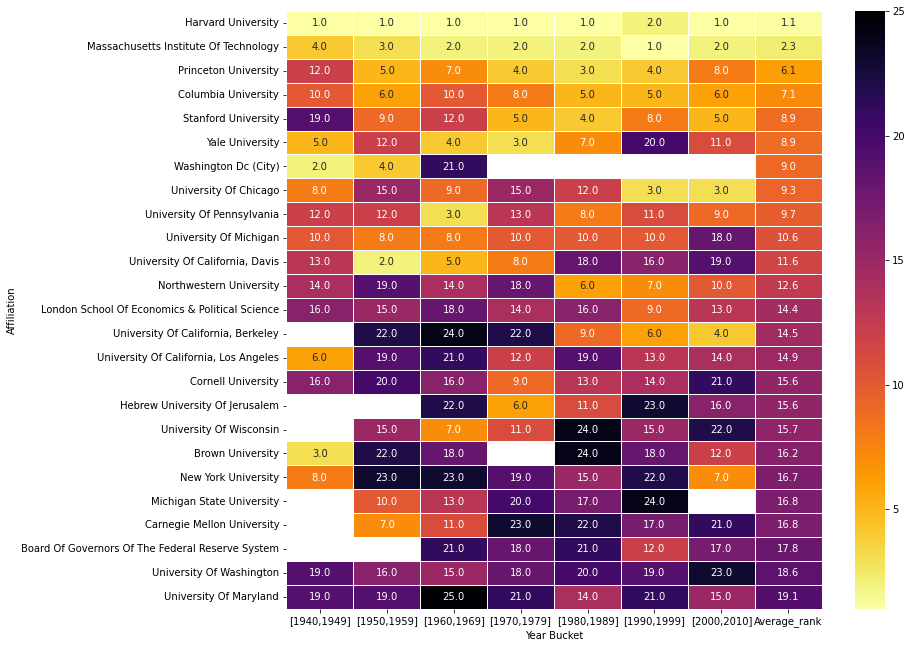

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt


ranked = ranked.replace(0, '')
invert_pivot = ranked.pivot(index='Affiliation', columns='Year Bucket', values='Rank')
invert_pivot['Average_rank'] = invert_pivot.mean(axis=1)

invert_pivot = invert_pivot.sort_values(by='Average_rank', ascending=True)


f, ax = plt.subplots(figsize=(12, 11))
cmap = plt.get_cmap('inferno_r')
sns.heatmap(invert_pivot, annot=True, fmt=".1f", cmap = cmap, linewidths=.5, ax=ax)

Year Bucket                                       [1940,1949]  [1950,1959]  \
Affiliation                                                                  
Board Of Governors Of The Federal Reserve System          NaN          NaN   
Brown University                                         10.0          1.5   
Carnegie Mellon University                                NaN          8.2   
Columbia University                                       4.5          8.5   
Cornell University                                        2.0          2.0   
Harvard University                                       49.0         38.2   
Hebrew University Of Jerusalem                            NaN          NaN   
London School Of Economics & Political Science            2.0          4.5   
Massachusetts Institute Of Technology                     9.0         14.5   
Michigan State University                                 NaN          5.5   
New York University                                       6.0   

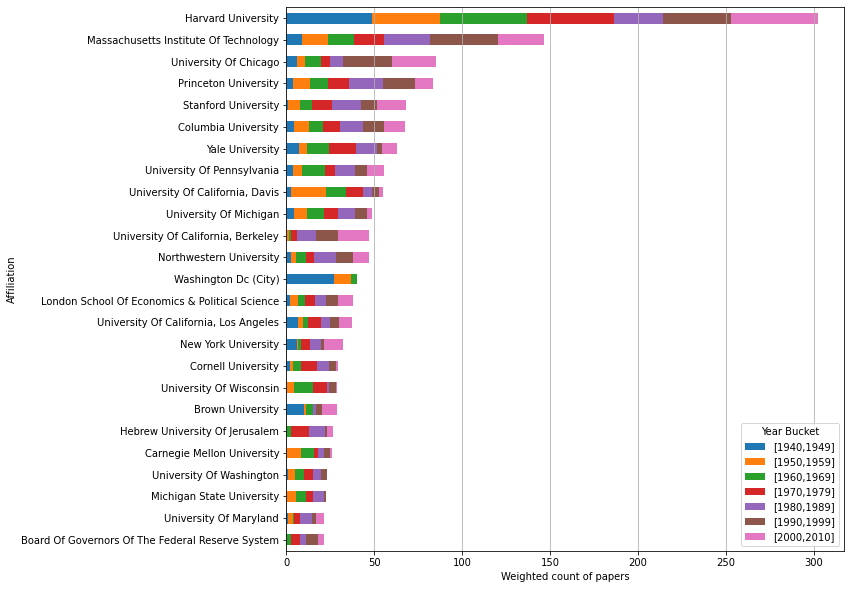

In [13]:
p = ranked.pivot(index='Affiliation', columns='Year Bucket', values='aff_cum_sum_decade')
print(p)
p['sum_cols'] = p.sum(axis=1)
p = p.sort_values(by='sum_cols', ascending=True)
p = p.drop(['sum_cols'], axis=1)

ax = p.plot.barh(stacked=True, figsize=(10, 10))
#plt.xticks(np.arange(0, 375, step=25))
plt.xlabel('Weighted count of papers')
plt.grid(axis = 'x')
plt.show()
